In [1]:
import FrameGenCombined
import KCF_tracker_v3_mt
import deepsort_acc
from pathlib import Path
import numpy as np
import pandas as pd

In [2]:
##### Generating Videos with moving debris #####


# set parameters
num_images = 20  # Number of images
num_frames = 450  # Number of new frames per image

# paths
file_dir = Path.cwd()# this is th directory where my jupyter notebook file was launched (requires 'from pathlib import Path')
train_csv = file_dir / "debris-detection/train.csv"
val_csv = file_dir / "debris-detection/val.csv"

test_dir = file_dir / "debris-detection/test"
train_dir = file_dir / "debris-detection/train"
val_dir = file_dir / "debris-detection/val"
output_dir = file_dir / "debris-detection/Generated_Images/Train"

np.random.seed(42)
df = FrameGenCombined.load_data(train_csv)
FrameGenCombined.process_vid_no_img(df, train_dir, output_dir, num_frames=num_frames, num_images=num_images, draw_bbox = 0, fps=30)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [02:34<00:00,  7.72s/it]

Finished processing


starting videos


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:08<00:00,  2.27it/s]


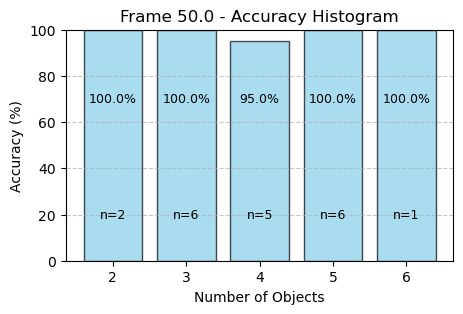

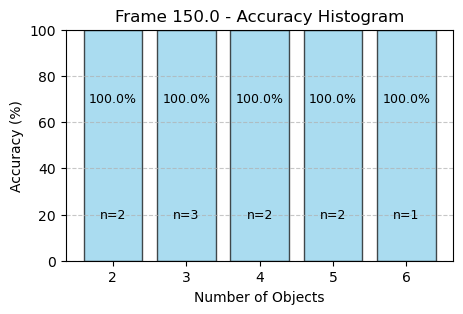

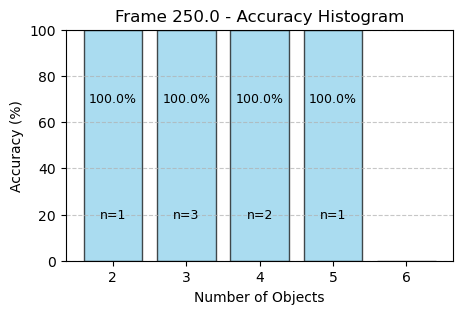

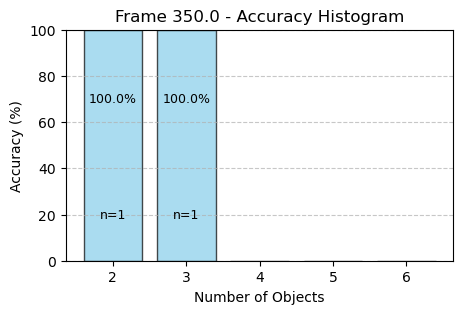

In [3]:
##### KCF Tracker #####

file_dir = Path.cwd()# this is the directory where my jupyter notebook file was launched (requires 'from pathlib import Path')
output_folder = file_dir / "debris-detection/Generated_Images/Train"


tolerance = 5
eval_interval = 100
nFrames = 450


n_steps = int((nFrames - eval_interval / 2) // eval_interval) + 1

accuracy_total = KCF_tracker_v3_mt.tracker_multi_thread(n_videos=20, n_start=0, reset_stats=True, showVid=False, nFrames=450, eval_interval=eval_interval, tolerance=5,output_folder=output_folder)

KCF_tracker_v3_mt.plot_histos_kcf(accuracy_total, eval_interval=eval_interval)

 95%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎              | 18/19 [00:28<00:01,  1.60s/it]


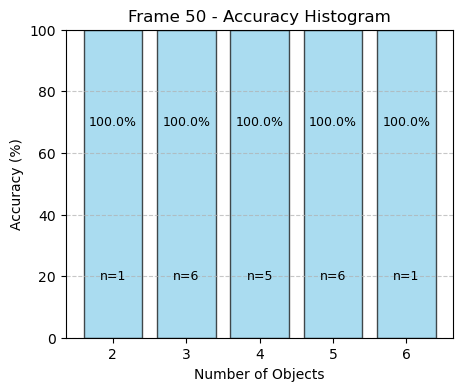

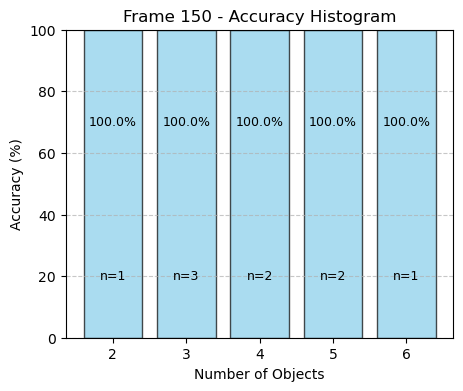

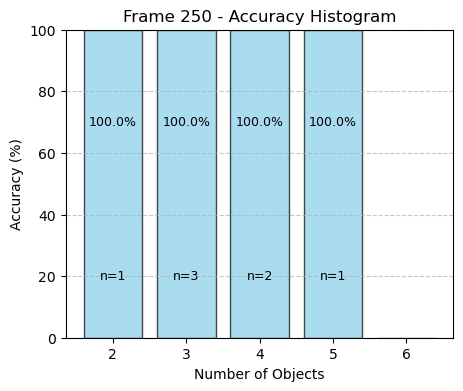

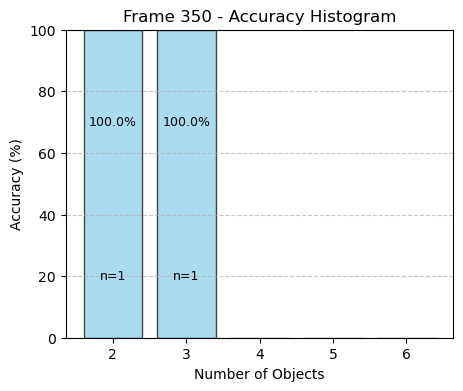

In [2]:
file_dir = Path.cwd()
output_dir = file_dir / "debris-detection/Generated_Images/Train"
train_csv = file_dir / "debris-detection/train.csv"
df = pd.read_csv(train_csv)

tolerance = 5
eval_interval = 100
nFrames = 450
nMaxObj = 8

accuracy_total = deepsort_acc.process_videos(df, output_dir, fps=30, num_images=19, nFrames=450, eval_interval=100, tolerance=5, nMaxObj=8)

deepsort_acc.plot_histos_DS(accuracy_total, eval_interval=eval_interval)